IN THIS FILE, WE WILL BE BUILDING, TRAINING AND SAVING THE TRAINED TRANSFER LEARNING MODEL.

In [13]:
# Importing the necessary libraries
import os
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [14]:
# Setting up the base path
base_dir = os.path.join('..', 'data', 'classification_dataset')

# Setting up the paths for train, valid and test data
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Setting up the parameters
batch_size = 32
img_size = (224,224)

In [15]:
# Data augmentation for the training data
train_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input,
                                      rotation_range=20,
                                      zoom_range=0.2,
                                      horizontal_flip=True,
                                      brightness_range=[0.8,1.2])

# Validation and test data (no augmentation)
test_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)

# Training data generator
train_gen_tl = train_datagen_tl.flow_from_directory(train_dir,
                                                    target_size=img_size,
                                                    batch_size=batch_size,
                                                    class_mode='binary')

# Validation data generator
valid_gen_tl = test_datagen_tl.flow_from_directory(valid_dir,
                                                   target_size=img_size,
                                                   batch_size=batch_size,
                                                   class_mode='binary')

# Test data generator
test_gen_tl = test_datagen_tl.flow_from_directory(test_dir,
                                                  target_size=img_size,
                                                  batch_size=batch_size,
                                                  class_mode='binary',
                                                  shuffle=False)

# Verifying the class indices
print("Class indices:", train_gen_tl.class_indices)

# Verifying batch shapes
x_batch, y_batch = next(train_gen_tl)
print("Batch shape:", x_batch.shape, y_batch.shape)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class indices: {'bird': 0, 'drone': 1}
Batch shape: (32, 224, 224, 3) (32,)


In [16]:
# Importing the necessary libraries for model building and training
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Loading the MobileNetV2 model without the top layers
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))

# Freezing the base model layers
base_model.trainable = False

In [18]:
# Adding custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

In [19]:
# Creating the full model by combining the base model and the custom layers
tl = Model(inputs=base_model.input, outputs=output)

In [20]:
# Compiling the model
tl.compile(optimizer=Adam(learning_rate=1e-4),
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [21]:
# Displaying the model 
tl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [22]:
# Callback to stop training early if validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss',
    patience=5,
    restore_best_weights=True)

# Callback to save the best model during training
checkpoint = ModelCheckpoint(filepath='../models/tl_model_best.h5',
    monitor='val_loss',
    save_best_only=True)

In [23]:
# Defining steps per epoch for consistent training
steps_per_epoch = len(train_gen_tl)
validation_steps = len(valid_gen_tl)

In [24]:
# Training the model
history = tl.fit(train_gen_tl,
                 steps_per_epoch=steps_per_epoch,
                 validation_data=valid_gen_tl,
                 validation_steps=validation_steps,
                 callbacks=[early_stop],
                 epochs=10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.8047 - loss: 0.4381 - val_accuracy: 0.9434 - val_loss: 0.1948
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.9196 - loss: 0.2062 - val_accuracy: 0.9525 - val_loss: 0.1278
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9358 - loss: 0.1593 - val_accuracy: 0.9570 - val_loss: 0.1072
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 225s 3s/step - accuracy: 0.9437 - loss: 0.1361 - val_accuracy: 0.9706 - val_loss: 0.0978
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.9545 - loss: 0.1220 - val_accuracy: 0.9751 - val_loss: 0.0925
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.9632 - loss: 0.0938 - val_accuracy: 0.9751 - val_loss: 0.0868
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.9673 - loss: 0.0923 - val_accuracy: 0.9751 - val_loss: 0.0853
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.9696 - loss: 0.0862 - val_accuracy: 0.9729 - v

In [25]:
# Fine tuning the last few layers of the base_model
for layers in base_model.layers[-30:]:
    layers.trainable = True

In [26]:
# Re-compiling with a lower learning rate
tl.compile(optimizer=Adam(learning_rate=1e-5),
           loss='binary_crossentropy',
           metrics=['accuracy'])

In [27]:
# Re-training the model with fine tuning
history_fine = tl.fit(train_gen_tl,
                      steps_per_epoch=steps_per_epoch,
                      validation_steps=validation_steps,
                      validation_data=valid_gen_tl,
                      callbacks=[early_stop, checkpoint],
                      epochs=10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9609 - loss: 0.1080

84/84 ━━━━━━━━━━━━━━━━━━━━ 374s 4s/step - accuracy: 0.9632 - loss: 0.1036 - val_accuracy: 0.9661 - val_loss: 0.0918
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 401s 5s/step - accuracy: 0.9636 - loss: 0.0932 - val_accuracy: 0.9638 - val_loss: 0.1059
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 397s 5s/step - accuracy: 0.9699 - loss: 0.0778 - val_accuracy: 0.9615 - val_loss: 0.1209
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 389s 5s/step - accuracy: 0.9767 - loss: 0.0630 - val_accuracy: 0.9638 - val_loss: 0.1048
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.9763 - loss: 0.0684 - val_accuracy: 0.9661 - val_loss: 0.1031


In [29]:
# Setting seaborn style for better visuals
sns.set(style="whitegrid")

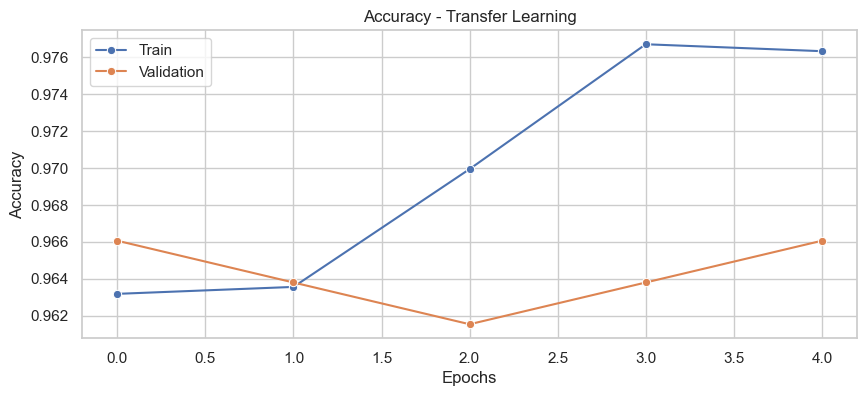

In [32]:
# Plotting the graph for accuracy
plt.figure(figsize=(10,4))
sns.lineplot(x=range(len(history_fine.history['accuracy'])), y=history_fine.history['accuracy'], label='Train', marker='o')
sns.lineplot(x=range(len(history_fine.history['val_accuracy'])), y=history_fine.history['val_accuracy'], label='Validation', marker='o')
plt.title('Accuracy - Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

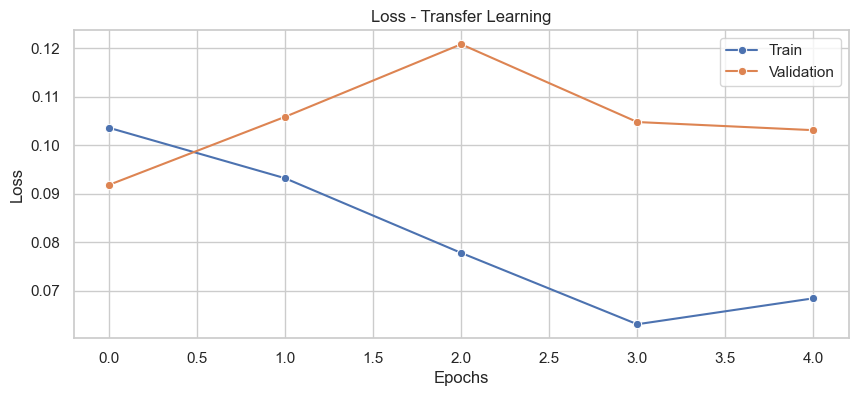

In [33]:
# Plotting the graph for loss
plt.figure(figsize=(10,4))
sns.lineplot(x=range(len(history_fine.history['loss'])), y=history_fine.history['loss'], label='Train', marker='o')
sns.lineplot(x=range(len(history_fine.history['val_loss'])), y=history_fine.history['val_loss'], label='Validation', marker='o')
plt.title('Loss - Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
# Prediction
y_pred_prob = tl.predict(test_gen_tl)
y_pred = (y_pred_prob > 0.5).astype(int)

# True Labels
y_true = test_gen_tl.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step


In [38]:
# Evaluating the model on the test set
test_loss, test_acc = tl.evaluate(test_gen_tl)
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['birds', 'drones']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9814 - loss: 0.0558
Test Accuracy: 0.9814
Classification Report:
              precision    recall  f1-score   support

       birds       0.99      0.98      0.98       121
      drones       0.97      0.99      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



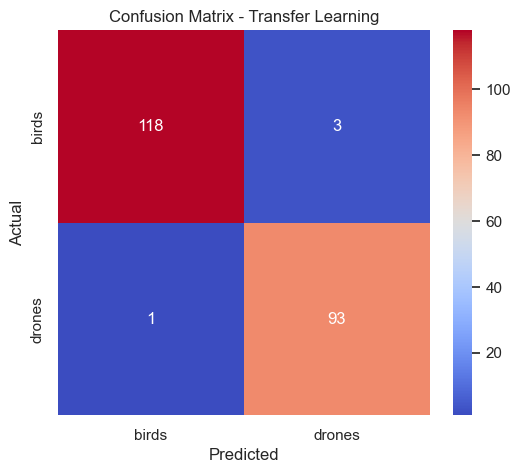

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting a heatmap for the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['birds', 'drones'], yticklabels=['birds', 'drones'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Transfer Learning')
plt.show()